###  <center> Imported From HPC



### <center> Machine Learning vs QRSIK3


In [1]:
import numpy as np                                
import pandas as pd                              
import matplotlib.pyplot as mtp                   
import matplotlib.pyplot as plt                  
import seaborn as sns                             
from sklearn.preprocessing import LabelEncoder    
import io
                                                                                                  
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

ModuleNotFoundError: No module named 'numpy'

### Data Exploration

In [ ]:
CVDRisk = []
CVDRisk = pd.read_csv('CVDRisk_final_ML.csv')
CVDRisk = CVDRisk.drop(columns=['Participant_ID']) 

#Creating list for categorical and numerical variables
cat=[]
cont=[]
for i in CVDRisk.columns:
    if CVDRisk[i].dtype=="object":
        cat.append(i)
    else:
        cont.append(i)
print('Categorical Variables:\n',cat) 
print()
print('Numeric Variables:\n',cont)

Categorical Variables:
 ['Sex', 'Smoking_Status_Qrisk3_1', 'Ethnicity', 'CKD', 'AF', 'Migraine', 'SLE', 'DMT1', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med', 'CVD_Outcome']

Numeric Variables:
 ['Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio']


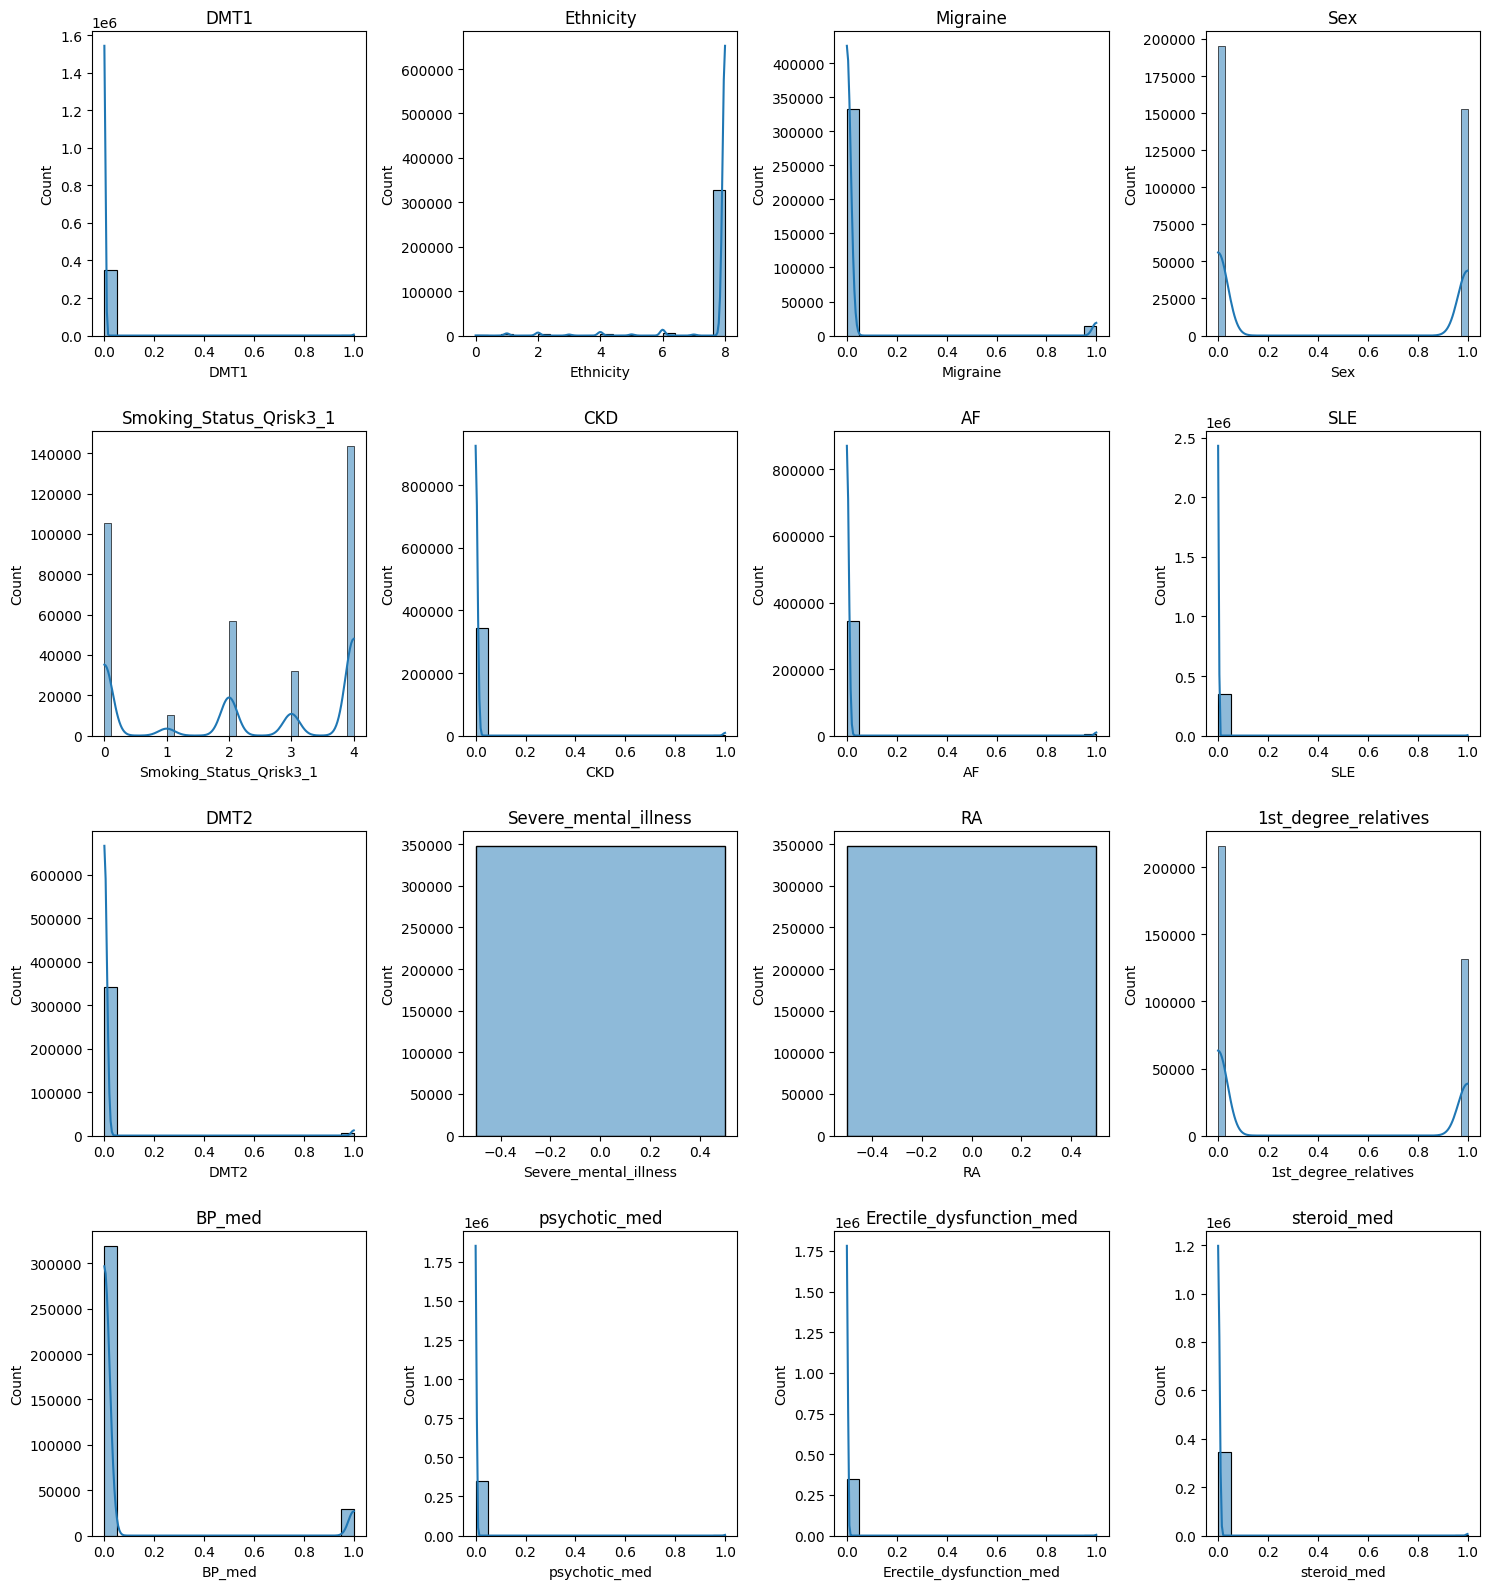

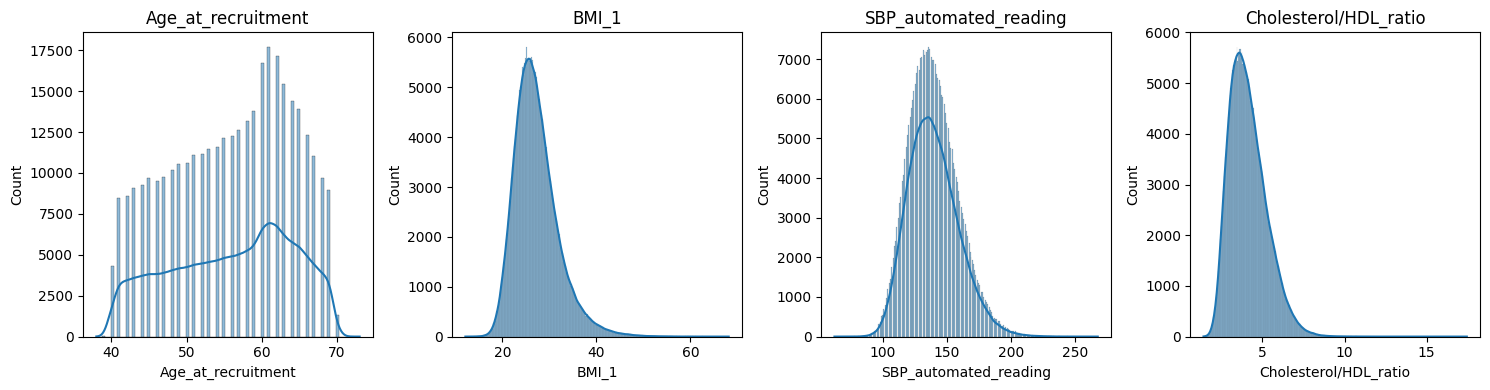

In [ ]:
# Define the target variable
target_variable = 'CVD_Outcome' 

# Define the feature variables
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine','Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    CVDRisk.drop(columns=[target_variable]), 
    CVDRisk[target_variable], 
    test_size=0.2, random_state=42
)

# Preprocessing: Standardize numeric variables
scaler = StandardScaler()
X_train[numeric_variables] = scaler.fit_transform(X_train[numeric_variables])
X_test[numeric_variables] = scaler.transform(X_test[numeric_variables])

# Define a function to evaluate model performance
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, precision, recall, f1

# Define a function to plot feature distributions
def plot_feature_distributions(CVDRisk, features):
    num_features = len(features)
    num_subplots = min(num_features, 16)  # Limit the number of subplots to 16
    num_rows = (num_subplots - 1) // 4 + 1
    num_cols = min(num_subplots, 4)
    
    plt.figure(figsize=(15, 4 * num_rows))
    for i, feature in enumerate(features[:num_subplots], 1):
        plt.subplot(num_rows, num_cols, i)
        sns.histplot(CVDRisk[feature], kde=True)
        plt.title(feature)
    plt.tight_layout()
    plt.show()


    
# Plot distributions of categorical variables
plot_feature_distributions(CVDRisk, categorical_variables)

# Plot distributions of numeric variables
plot_feature_distributions(CVDRisk, numeric_variables)

### 1. Logistic Regression

Logistis Regression Results:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.37      0.00      0.01      4626

    accuracy                           0.93     69603
   macro avg       0.65      0.50      0.49     69603
weighted avg       0.90      0.93      0.90     69603

Logistic Regression Model Results:
Accuracy: 0.9334
Precision: 0.3714
Recall: 0.0028
F1-score: 0.0056
Precision: 0.6526
Recall: 0.5012
F1-score: 0.4856


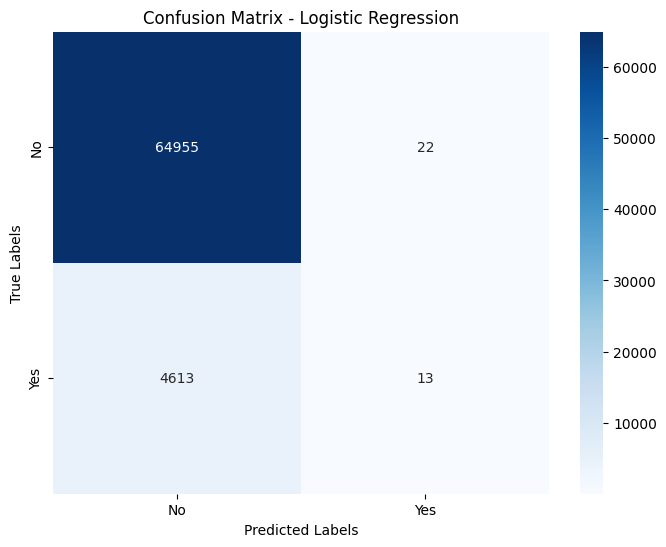

Logistic Regression Model AUC: 0.7195


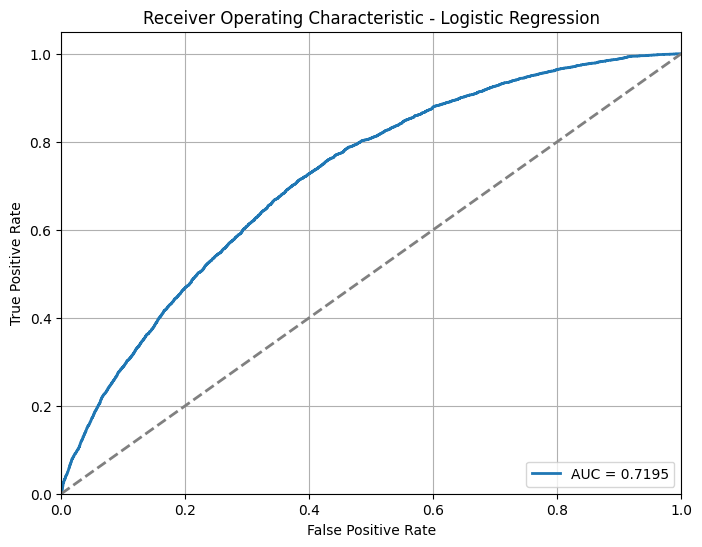

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression model
logistic_regression = LogisticRegression()

# Train the model
logistic_regression.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = logistic_regression.predict(X_test)

# Predict probabilities on the test set and select the probabilities for the positive class
y_prob_lr = logistic_regression.predict_proba(X_test)[:, 1]

# Evaluate model performance
classification_rep_lr = classification_report(y_test, y_pred_lr, target_names=['no', 'yes'], zero_division=1)

# Display classification report
print("Logistis Regression Results:")
print(classification_rep_lr)

# Evaluate model performance
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

precision_lr_macro = precision_score(y_test, y_pred_lr, average='macro')
recall_lr_macro = recall_score(y_test, y_pred_lr, average='macro')
f1_lr_macro = f1_score(y_test, y_pred_lr, average='macro')


# Display results
print("Logistic Regression Model Results:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print(f"Precision: {precision_lr_macro:.4f}")
print(f"Recall: {recall_lr_macro:.4f}")
print(f"F1-score: {f1_lr_macro:.4f}")

# Generate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ROC Analysis

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Calculate AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"Logistic Regression Model AUC: {auc_lr:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc_lr:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

### 2. Decision Tree

Decision Tree Classifier Results:
              precision    recall  f1-score   support

          no       0.94      0.93      0.93     64977
         yes       0.11      0.12      0.11      4626

    accuracy                           0.87     69603
   macro avg       0.52      0.52      0.52     69603
weighted avg       0.88      0.87      0.88     69603

Decision Tree Classifier Results:
Accuracy: 0.8735
Precision: 0.1058
Recall: 0.1213
F1-score: 0.5225
Precision: 0.5213
Recall: 0.5242
F1-score: 0.5225


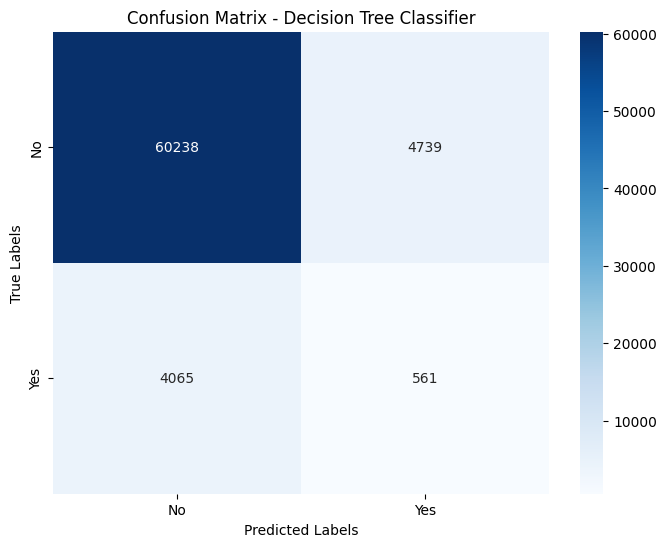

Decision Tree Classifier AUC: 0.5242


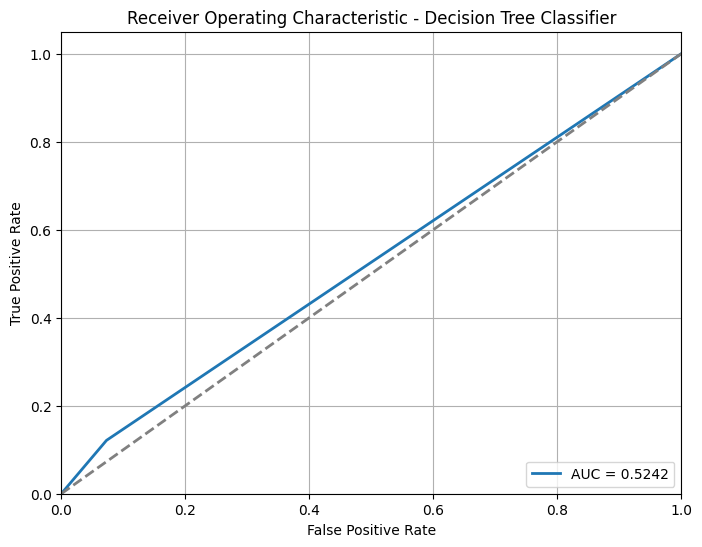

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Decision Tree Classifier model
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Predict probabilities on the test set and select the probabilities for the positive class
y_prob_dt = dt_classifier.predict_proba(X_test)[:, 1]

# Evaluate model performance
classification_rep_dt = classification_report(y_test, y_pred_dt, target_names=['no', 'yes'], zero_division=1)

# Display classification report
print("Decision Tree Classifier Results:")
print(classification_rep_dt)

# Evaluate model performance
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
precision_dt_macro = precision_score(y_test, y_pred_dt, average='macro')
recall_dt_macro = recall_score(y_test, y_pred_dt, average='macro')
f1_dt_macro = f1_score(y_test, y_pred_dt, average='macro')

# Display results
print("Decision Tree Classifier Results:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt_macro:.4f}")
print(f"Precision: {precision_dt_macro:.4f}")
print(f"Recall: {recall_dt_macro:.4f}")
print(f"F1-score: {f1_dt_macro:.4f}")

# Generate confusion matrix for Decision Tree Classifier
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

# ROC Analysis
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

# Calculate AUC
auc_dt = roc_auc_score(y_test, y_prob_dt)
print(f"Decision Tree Classifier AUC: {auc_dt:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc_dt:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Decision Tree Classifier')
plt.grid(True)
plt.legend(loc="lower right")
plt.show()


### 3. Random Forest

Random Forest Classifier Results:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.30      0.00      0.01      4626

    accuracy                           0.93     69603
   macro avg       0.61      0.50      0.49     69603
weighted avg       0.89      0.93      0.90     69603

Random Forest Classifier Results:
Accuracy: 0.9333
Precision: 0.2955
Recall: 0.0028
F1-score: 0.4855
Precision: 0.6146
Recall: 0.5012
F1-score: 0.4855


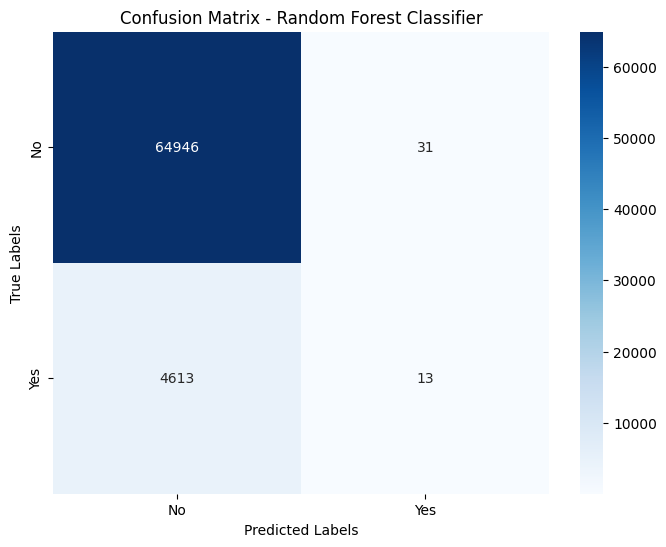

Random Forest Classifier AUC: 0.6776


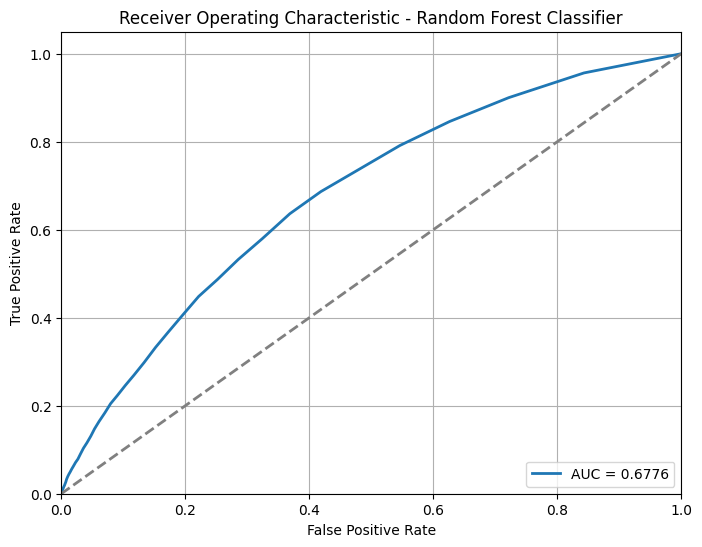

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Predict probabilities on the test set and select the probabilities for the positive class
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate model performance
classification_rep_rf = classification_report(y_test, y_pred_rf, target_names=['no', 'yes'], zero_division=1)

# Display classification report
print("Random Forest Classifier Results:")
print(classification_rep_rf)

# Evaluate model performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf_macro = precision_score(y_test, y_pred_rf, average='macro')
recall_rf_macro = recall_score(y_test, y_pred_rf, average='macro')
f1_rf_macro = f1_score(y_test, y_pred_rf, average='macro')


# Display results
print("Random Forest Classifier Results:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf_macro:.4f}")
print(f"Precision: {precision_rf_macro:.4f}")
print(f"Recall: {recall_rf_macro:.4f}")
print(f"F1-score: {f1_rf_macro:.4f}")

# Generate confusion matrix for Random Forest Classifier
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

# ROC Analysis
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Calculate AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest Classifier AUC: {auc_rf:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc_rf:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest Classifier')
plt.grid(True)
plt.legend(loc="lower right")
plt.show()


### 4. Naive Bayes

Naive Bayes Classifier Results:
              precision    recall  f1-score   support

          no       0.94      0.96      0.95     64977
         yes       0.16      0.12      0.14      4626

    accuracy                           0.90     69603
   macro avg       0.55      0.54      0.54     69603
weighted avg       0.89      0.90      0.89     69603

Naive Bayes Classifier Results:
Accuracy: 0.8996
Precision: 0.1593
Recall: 0.1193
F1-score: 0.1364
Precision: 0.5488
Recall: 0.5372
F1-score: 0.5416


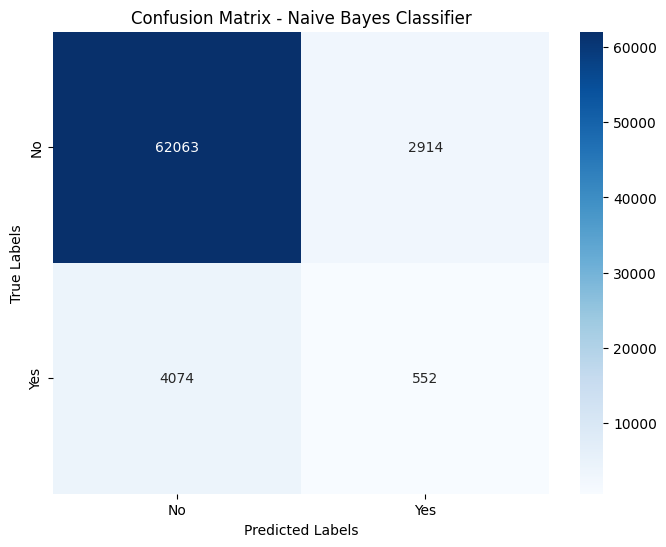

Naive Bayes Classifier AUC: 0.7045


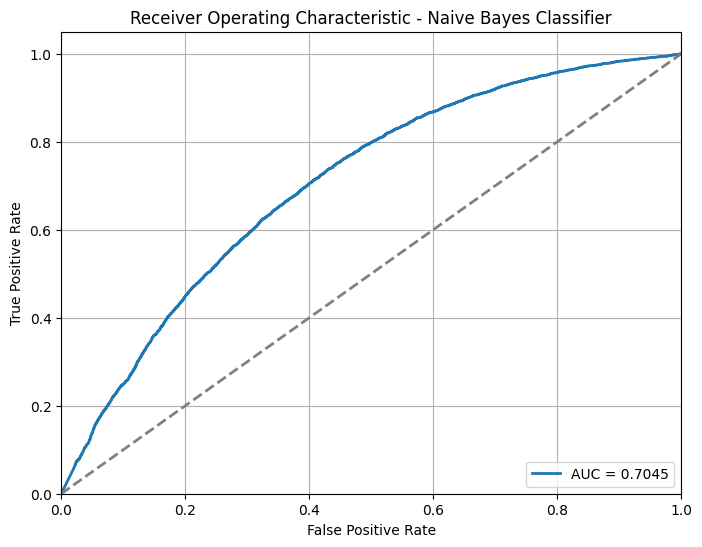

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Initialize Naive Bayes classifier
naive_bayes_classifier = GaussianNB()

# Train the model
naive_bayes_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_nb = naive_bayes_classifier.predict(X_test)

# Predict probabilities on the test set and select the probabilities for the positive class
y_prob_nb = naive_bayes_classifier.predict_proba(X_test)[:, 1]

# Evaluate model performance
classification_rep_nb = classification_report(y_test, y_pred_nb, target_names=['no', 'yes'], zero_division=1)

# Display classification report
print("Naive Bayes Classifier Results:")
print(classification_rep_nb)

# Evaluate model performance
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
precision_nb_macro = precision_score(y_test, y_pred_nb, average='macro')
recall_nb_macro = recall_score(y_test, y_pred_nb, average='macro')
f1_nb_macro = f1_score(y_test, y_pred_nb, average='macro')

# Display results
print("Naive Bayes Classifier Results:")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-score: {f1_nb:.4f}")
print(f"Precision: {precision_nb_macro:.4f}")
print(f"Recall: {recall_nb_macro:.4f}")
print(f"F1-score: {f1_nb_macro:.4f}")

# Generate confusion matrix for Naive Bayes Classifier
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.show()

# ROC Analysis
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)

# Calculate AUC
auc_nb = roc_auc_score(y_test, y_prob_nb)
print(f"Naive Bayes Classifier AUC: {auc_nb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc_nb:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Naive Bayes Classifier')
plt.grid(True)
plt.legend(loc="lower right")
plt.show()


### 5. Gradient Boosting

Gradient Boosting Classifier Results:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.41      0.00      0.00      4626

    accuracy                           0.93     69603
   macro avg       0.67      0.50      0.48     69603
weighted avg       0.90      0.93      0.90     69603

Gradient Boosting Results:
Accuracy: 0.9335
Precision: 0.4091
Recall: 0.0019
F1-score: 0.0039
Precision: 0.6714
Recall: 0.5009
F1-score: 0.4847


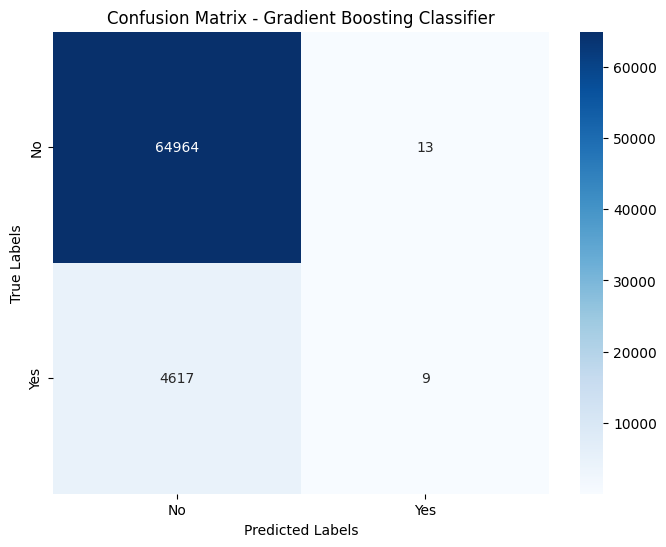

Gradient Boosting Classifier AUC: 0.7253


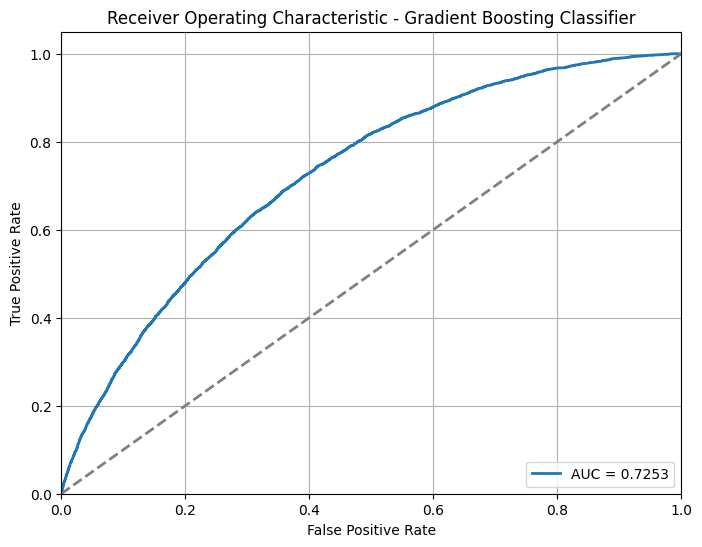

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Initialize the Gradient Boosting classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the model
gb_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_classifier.predict(X_test)

# Predict probabilities on the test set and select the probabilities for the positive class
y_prob_gb = gb_classifier.predict_proba(X_test)[:, 1]

# Evaluate model performance
classification_rep_gb = classification_report(y_test, y_pred_gb, target_names=['no', 'yes'], zero_division=1)

# Display classification report
print("Gradient Boosting Classifier Results:")
print(classification_rep_gb)

# Evaluate model performance
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
precision_gb_macro = precision_score(y_test, y_pred_gb, average='macro')
recall_gb_macro = recall_score(y_test, y_pred_gb, average='macro')
f1_gb_macro = f1_score(y_test, y_pred_gb, average='macro')

# Display results
print("Gradient Boosting Results:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")
print(f"Precision: {precision_gb_macro:.4f}")
print(f"Recall: {recall_gb_macro:.4f}")
print(f"F1-score: {f1_gb_macro:.4f}")

# Generate confusion matrix for Gradient Boosting Classifier
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.show()

# ROC Analysis
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)

# Calculate AUC
auc_gb = roc_auc_score(y_test, y_prob_gb)
print(f"Gradient Boosting Classifier AUC: {auc_gb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc_gb:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Gradient Boosting Classifier')
plt.grid(True)
plt.legend(loc="lower right")
plt.show()


### 1. Logistic Regression with PSO

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

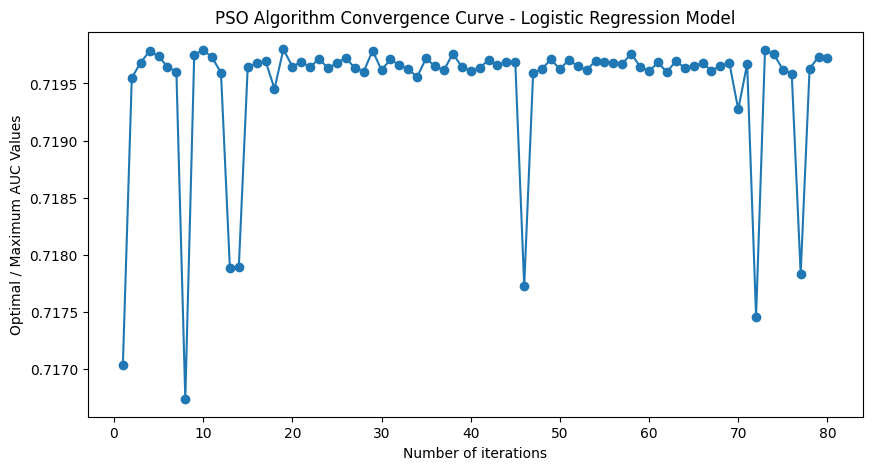

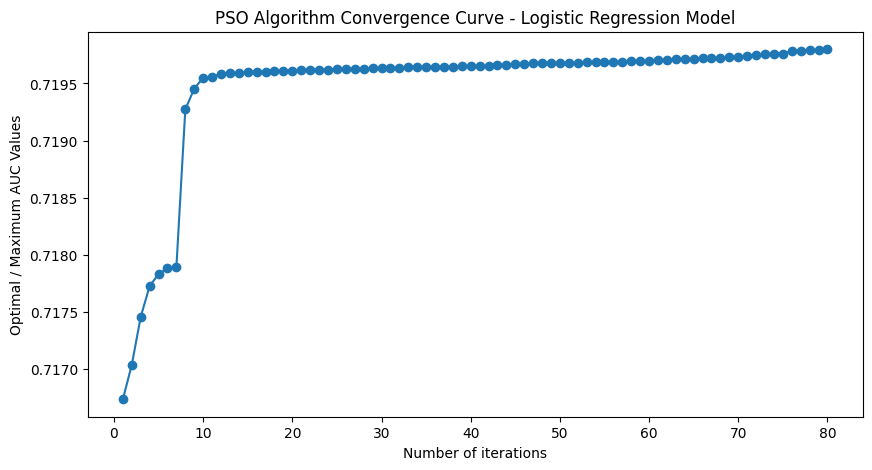

AUC after PSO (using selected features): 0.7197


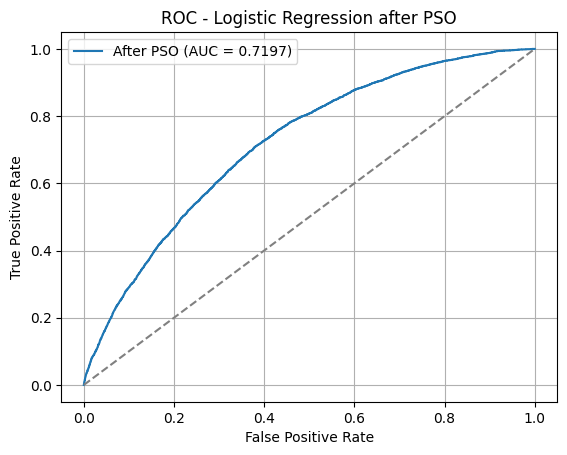

Best AUC: 0.7198
Best Features: [16, 14, 10, 3, 1, 12, 0, 13, 4, 7, 11, 5, 8, 2, 18, 6, 15, 19]
Feature Names: ['BP_med', 'RA', 'SLE', 'SBP_automated_reading', 'Sex', 'DMT2', 'Age_at_recruitment', 'Severe_mental_illness', 'Cholesterol/HDL_ratio', 'CKD', 'DMT1', 'Smoking_Status_Qrisk3_1', 'AF', 'BMI_1', 'Erectile_dysfunction_med', 'Ethnicity', '1st_degree_relatives', 'steroid_med']
Logistic Regression Results with PSO Feature Selection:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.36      0.00      0.01      4626

    accuracy                           0.93     69603
   macro avg       0.65      0.50      0.49     69603
weighted avg       0.90      0.93      0.90     69603

Accuracy: 0.9334
Precision: 0.3590
Recall: 0.0030
F1-score: 0.0060
Precision: 0.6714
Recall: 0.5009
F1-score: 0.4847


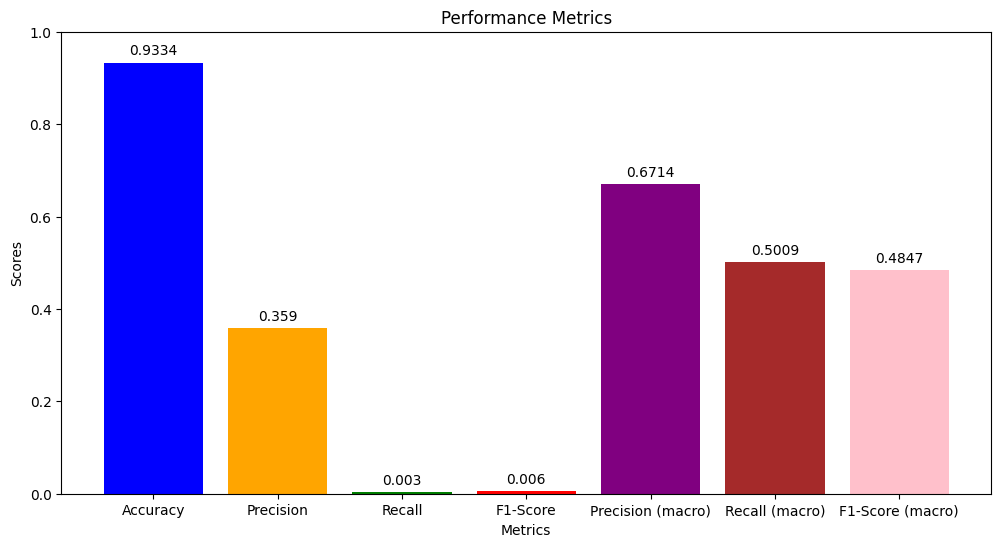

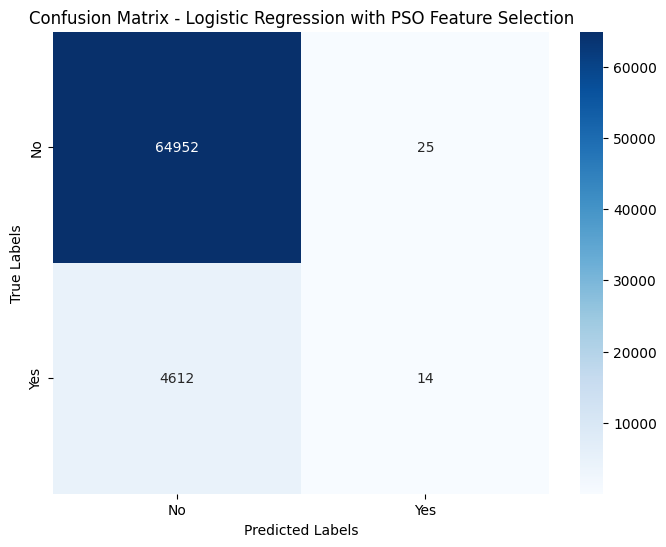

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = LogisticRegression()
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Logistic Regression Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Logistic Regression Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Get the best features data
best_features_data = X.iloc[:, best_features].values
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the logistic regression model using the best features
best_model = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_lr = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_lr = roc_auc_score(y_test_best, y_pred_prob_best_lr)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_lr:.4f}")

# ROC Analysis
fpr_best_lr, tpr_best_lr, _ = roc_curve(y_test_best, y_pred_prob_best_lr)

plt.figure()
plt.plot(fpr_best_lr, tpr_best_lr, label=f'After PSO (AUC = {auc_after_pso_lr:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Logistic Regression Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best_macro = precision_score(y_test, y_pred_gb, average='macro')
recall_best_macro = recall_score(y_test, y_pred_gb, average='macro')
f1_best_macro = f1_score(y_test, y_pred_gb, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision: {precision_best_macro:.4f}")
print(f"Recall: {recall_best_macro:.4f}")
print(f"F1-score: {f1_best_macro:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best_macro, recall_best_macro, f1_best_macro]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Decision Tree Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Logistic Regression with PSO Feature Selection')
plt.show()

### 2. Decision Tree with PSO Algorithm

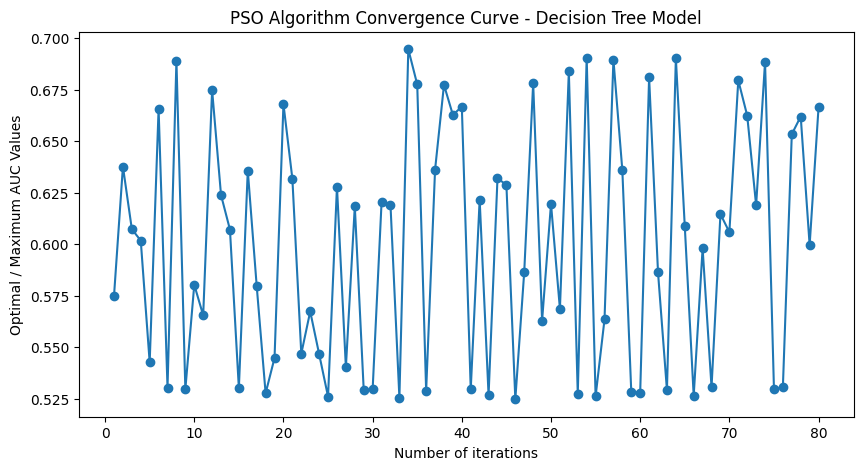

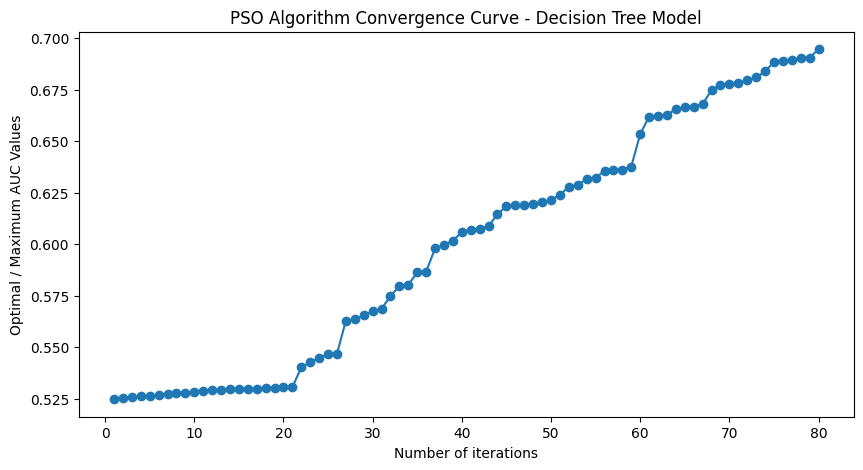

AUC after PSO (using selected features): 0.6947


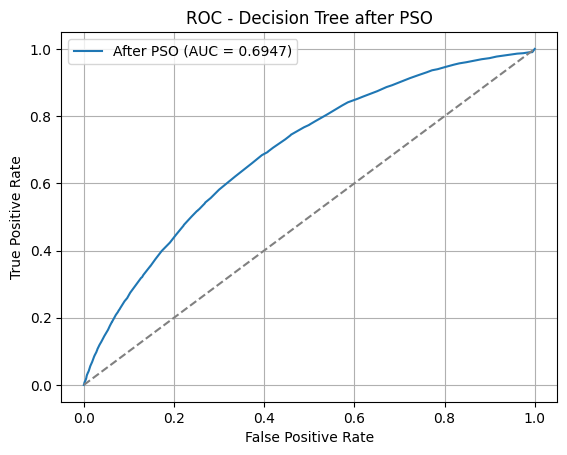

Best AUC: 0.6947
Best Features: [1, 19, 18, 13, 16, 14, 8, 10, 11, 0, 12]
Feature Names: ['Sex', 'steroid_med', 'Erectile_dysfunction_med', 'Severe_mental_illness', 'BP_med', 'RA', 'AF', 'SLE', 'DMT1', 'Age_at_recruitment', 'DMT2']
Decision Tree Classifier Results with PSO Feature Selection:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.22      0.00      0.00      4626

    accuracy                           0.93     69603
   macro avg       0.58      0.50      0.49     69603
weighted avg       0.89      0.93      0.90     69603

Accuracy: 0.9331
Precision: 0.2245
Recall: 0.0024
F1-score: 0.0047
Precision: 0.5791
Recall: 0.5009
F1-score: 0.4851


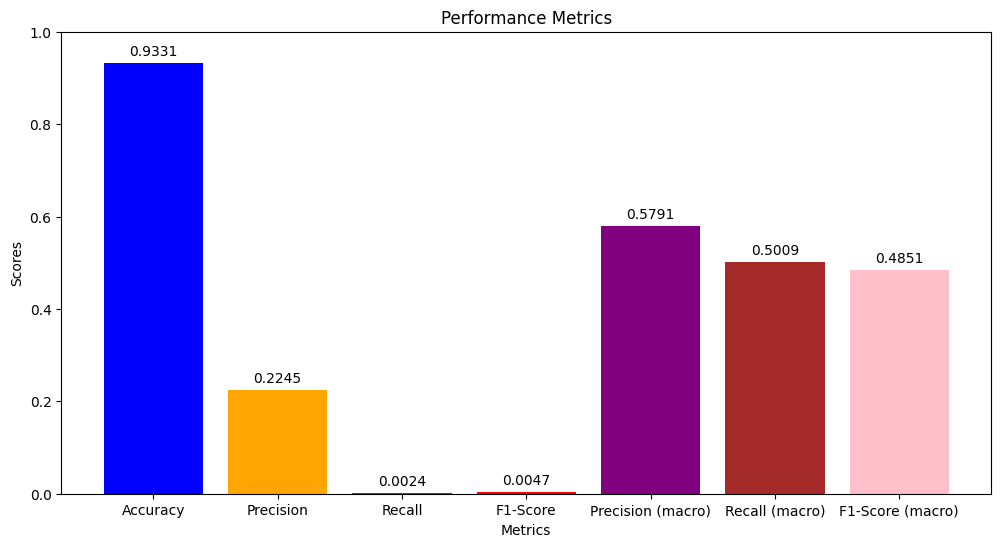

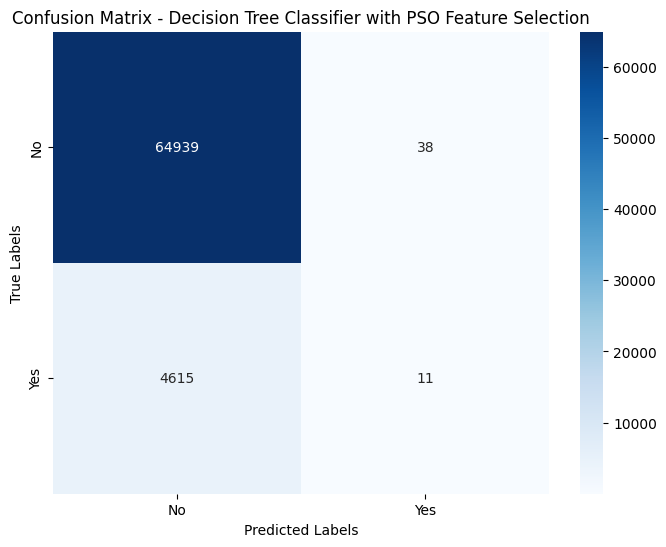

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = DecisionTreeClassifier(random_state=42)
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Decision Tree Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Decision Tree Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Get the best features data
best_features_data = X.iloc[:, best_features].values
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the Decision Tree model using the best features
best_model = DecisionTreeClassifier(random_state=42) 
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_dt = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_dt = roc_auc_score(y_test_best, y_pred_prob_best_dt)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_dt:.4f}")

# ROC Analysis
fpr_best_dt, tpr_best_dt, _ = roc_curve(y_test_best, y_pred_prob_best_dt)

plt.figure()
plt.plot(fpr_best_dt, tpr_best_dt, label=f'After PSO (AUC = {auc_after_pso_dt:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Decision Tree after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Decision Tree Classifier Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best_macro = precision_score(y_test_best, y_pred_best, average='macro')
recall_best_macro = recall_score(y_test_best, y_pred_best, average='macro')
f1_best_macro = f1_score(y_test_best, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision: {precision_best_macro:.4f}")
print(f"Recall: {recall_best_macro:.4f}")
print(f"F1-score: {f1_best_macro:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best_macro, recall_best_macro, f1_best_macro]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Decision Tree Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Decision Tree Classifier with PSO Feature Selection')
plt.show()


### 3. Random Forest with PSO Algorithm

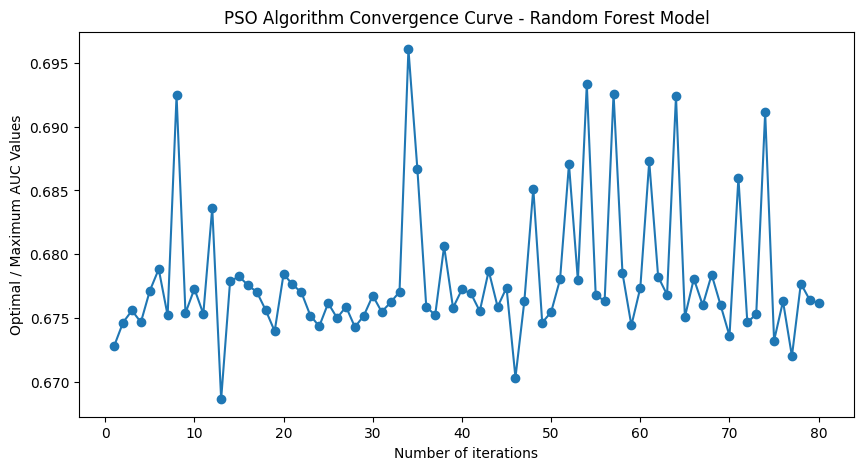

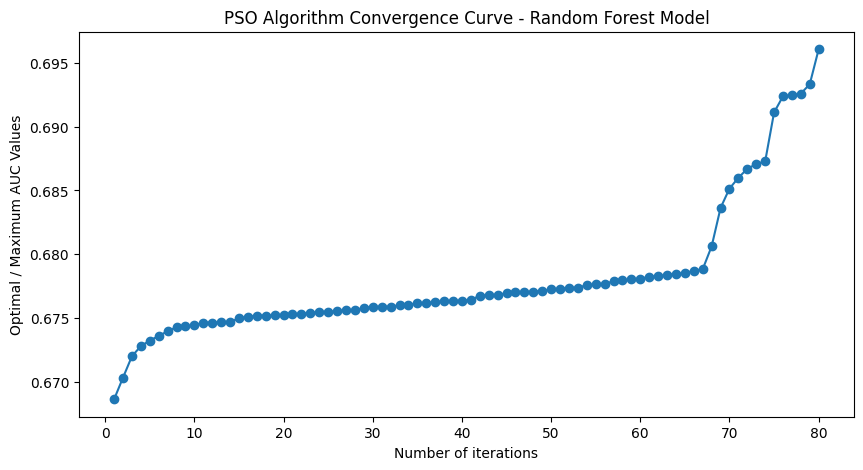

AUC after PSO (using selected features): 0.6961


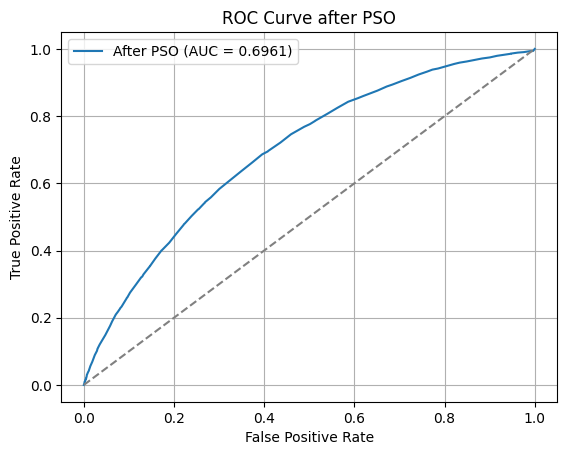

Best AUC: 0.6961
Best Features: [1, 19, 18, 13, 16, 14, 8, 10, 11, 0, 12]
Feature Names: ['Sex', 'steroid_med', 'Erectile_dysfunction_med', 'Severe_mental_illness', 'BP_med', 'RA', 'AF', 'SLE', 'DMT1', 'Age_at_recruitment', 'DMT2']
Random Forest Classifier Results with PSO Feature Selection:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.21      0.00      0.01      4626

    accuracy                           0.93     69603
   macro avg       0.57      0.50      0.49     69603
weighted avg       0.89      0.93      0.90     69603

Accuracy: 0.9331
Precision: 0.5721
Recall: 0.5010
F1-score: 0.4852
Precision: 0.5791
Recall: 0.5009
F1-score: 0.4851


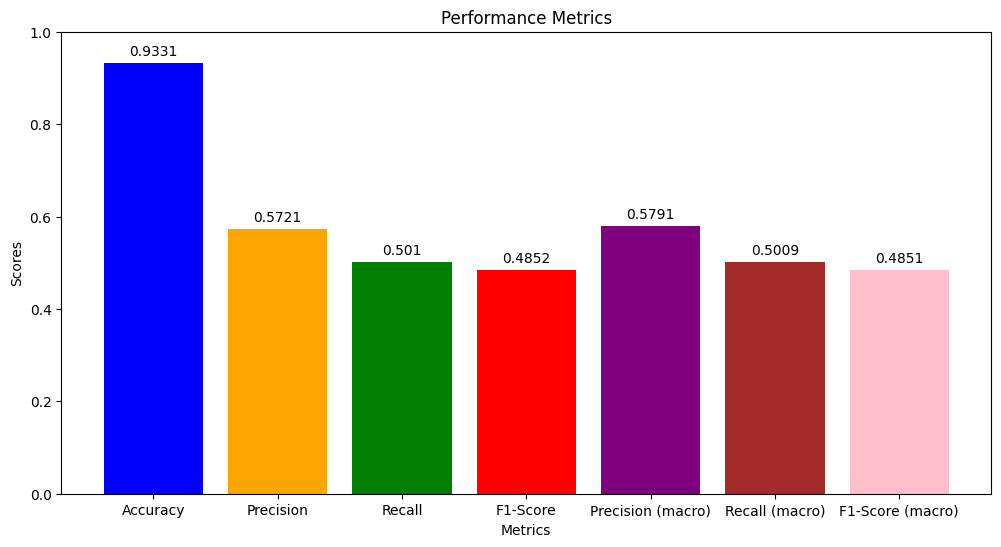

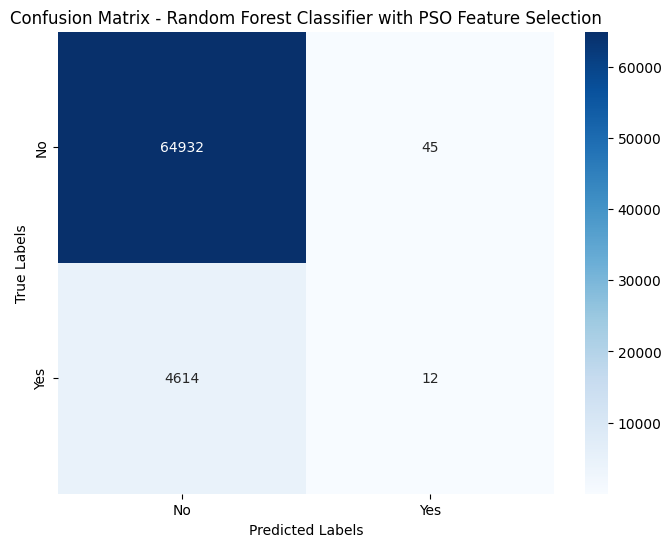

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)


target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Random Forest Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Random Forest Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()


# Get the best features data
best_features_data = X.iloc[:, best_features].values
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the Random Forest model using the best features
best_model = RandomForestClassifier(n_estimators=100, random_state=42) # Increased max_iter
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_rf = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_rf = roc_auc_score(y_test_best, y_pred_prob_best_rf)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_rf:.4f}")

# ROC Analysis
fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test_best, y_pred_prob_best_rf)

plt.figure()
plt.plot(fpr_best_rf, tpr_best_rf, label=f'After PSO (AUC = {auc_after_pso_rf:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Random Forest Classifier Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best, average='macro')
recall_best = recall_score(y_test_best, y_pred_best, average='macro')
f1_best = f1_score(y_test_best, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision: {precision_best_macro:.4f}")
print(f"Recall: {recall_best_macro:.4f}")
print(f"F1-score: {f1_best_macro:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best_macro, recall_best_macro, f1_best_macro]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Random Forest Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Random Forest Classifier with PSO Feature Selection')
plt.show()


### 4. Naive Bayes with PSO Algorithm

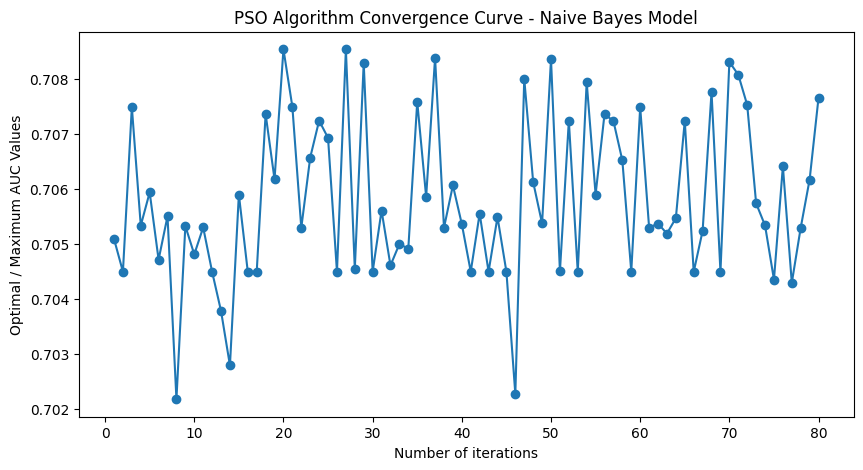

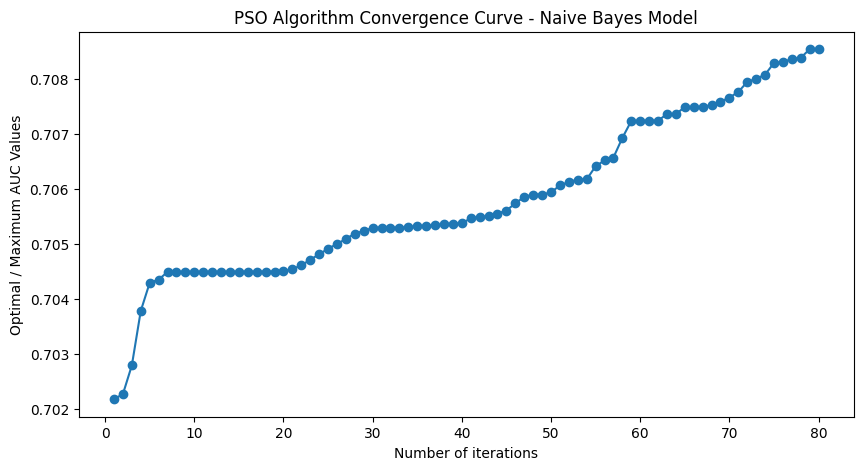

AUC after PSO (using selected features): 0.7085


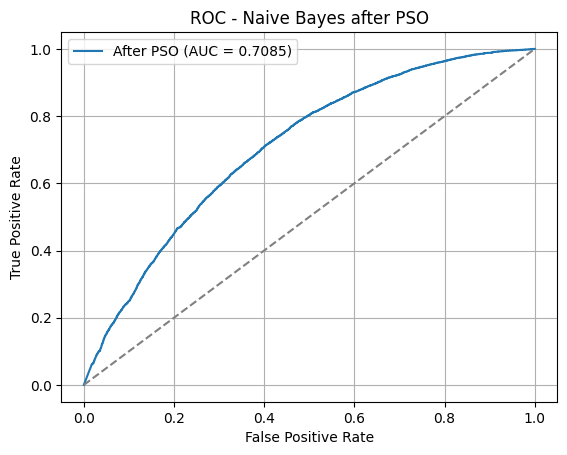

Best AUC: 0.7085
Best Features: [8, 16, 7, 1, 15, 3, 12, 18, 2, 4, 0, 10, 9]
Feature Names: ['AF', 'BP_med', 'CKD', 'Sex', '1st_degree_relatives', 'SBP_automated_reading', 'DMT2', 'Erectile_dysfunction_med', 'BMI_1', 'Cholesterol/HDL_ratio', 'Age_at_recruitment', 'SLE', 'Migraine']
Naive Bayes Classifier Results with PSO Feature Selection:
              precision    recall  f1-score   support

          no       0.94      0.95      0.95     64977
         yes       0.18      0.14      0.16      4626

    accuracy                           0.90     69603
   macro avg       0.56      0.55      0.55     69603
weighted avg       0.89      0.90      0.89     69603

Accuracy: 0.9000
Precision: 0.5597
Recall: 0.5478
F1-score: 0.5526
Precision: 0.5791
Recall: 0.5009
F1-score: 0.4851


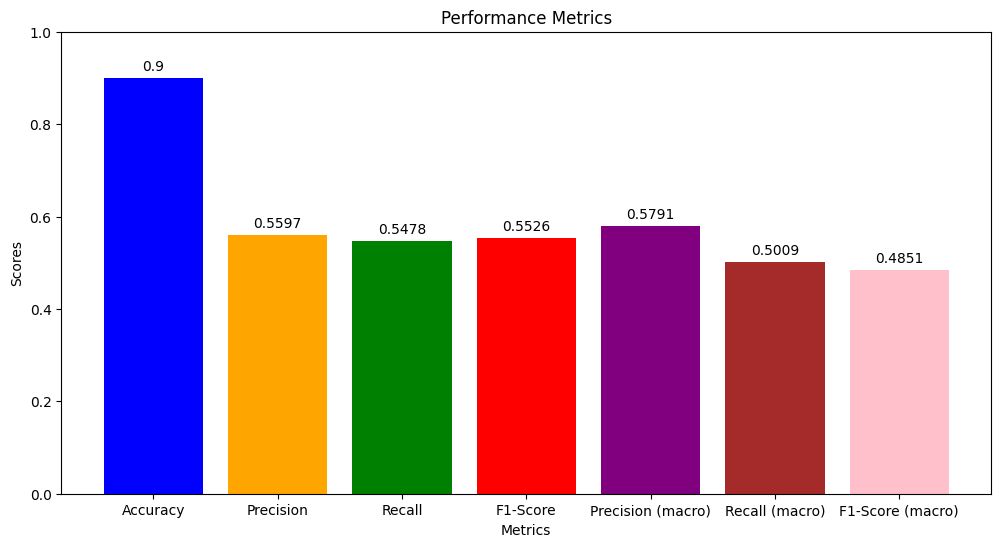

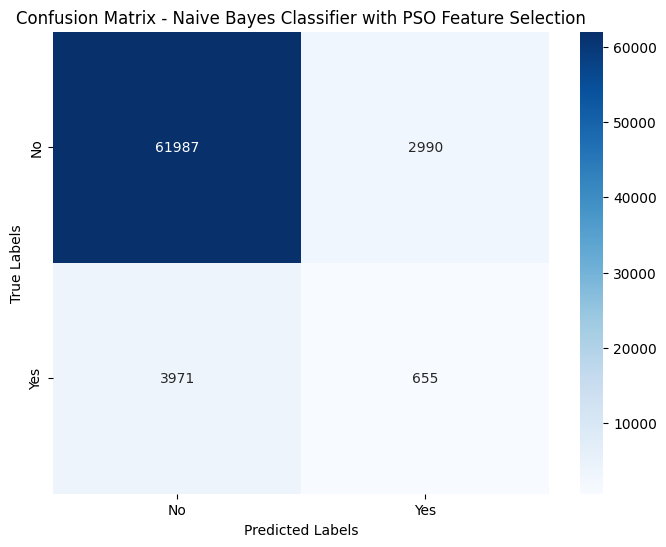

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = GaussianNB()
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Naive Bayes Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Naive Bayes Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Get the best features data
best_features_data = X.iloc[:, best_features].values
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the Naive Bayes model using the best features
best_model = GaussianNB ()
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_nb = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_nb = roc_auc_score(y_test_best, y_pred_prob_best_nb)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_nb:.4f}")

# ROC Analysis
fpr_best_nb, tpr_best_nb, _ = roc_curve(y_test_best, y_pred_prob_best_nb)

plt.figure()
plt.plot(fpr_best_nb, tpr_best_nb, label=f'After PSO (AUC = {auc_after_pso_nb:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Naive Bayes after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Naive Bayes Classifier Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best, average='macro')
recall_best = recall_score(y_test_best, y_pred_best, average='macro')
f1_best = f1_score(y_test_best, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision: {precision_best_macro:.4f}")
print(f"Recall: {recall_best_macro:.4f}")
print(f"F1-score: {f1_best_macro:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best_macro, recall_best_macro, f1_best_macro]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Naive Bayes Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Naive Bayes Classifier with PSO Feature Selection')
plt.show()


### 5. Gradient Boosting with PSO Algorithm 

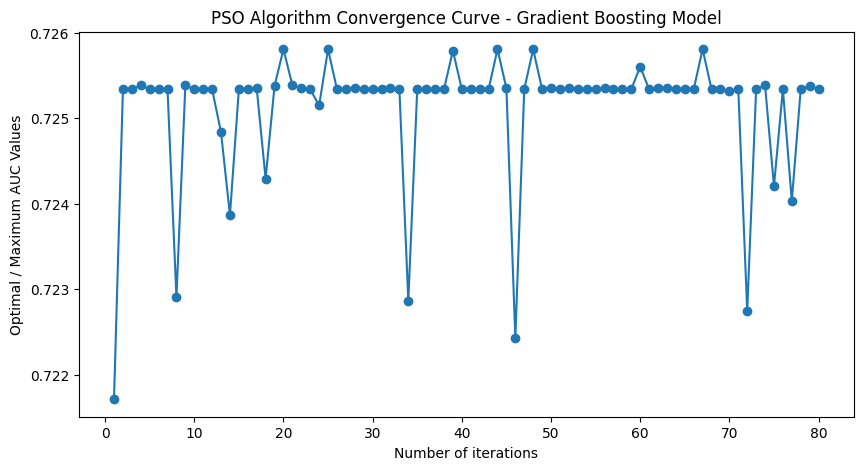

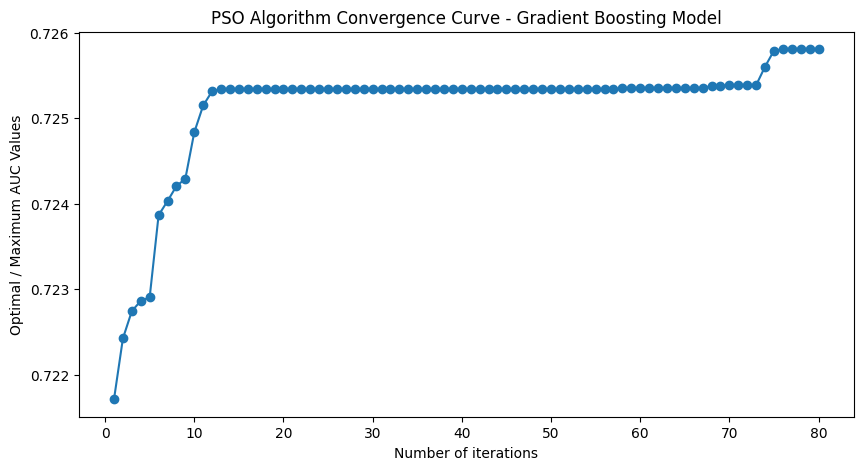

AUC after PSO (using selected features): 0.7258


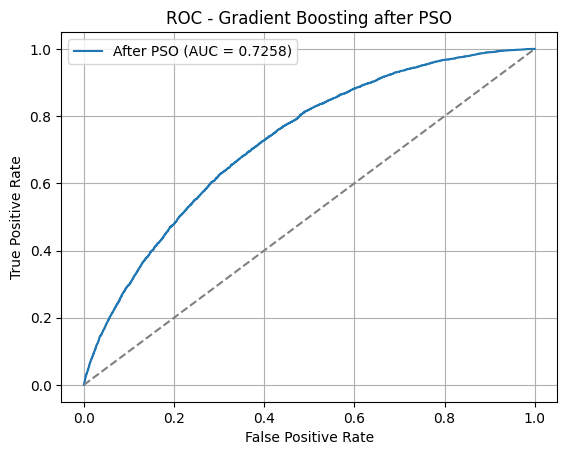

Best AUC: 0.7258
Best Features: [13, 1, 6, 8, 4, 15, 7, 10, 3, 18, 5, 9, 17, 2, 19, 12, 16, 0]
Feature Names: ['Severe_mental_illness', 'Sex', 'Ethnicity', 'AF', 'Cholesterol/HDL_ratio', '1st_degree_relatives', 'CKD', 'SLE', 'SBP_automated_reading', 'Erectile_dysfunction_med', 'Smoking_Status_Qrisk3_1', 'Migraine', 'psychotic_med', 'BMI_1', 'steroid_med', 'DMT2', 'BP_med', 'Age_at_recruitment']
Gradient Boosting Classifier Results with PSO Feature Selection:
              precision    recall  f1-score   support

          no       0.93      1.00      0.97     64977
         yes       0.33      0.00      0.00      4626

    accuracy                           0.93     69603
   macro avg       0.63      0.50      0.48     69603
weighted avg       0.89      0.93      0.90     69603

Accuracy: 0.9335
Precision: 0.6335
Recall: 0.5005
F1-score: 0.4839
Precision: 0.5791
Recall: 0.5009
F1-score: 0.4851


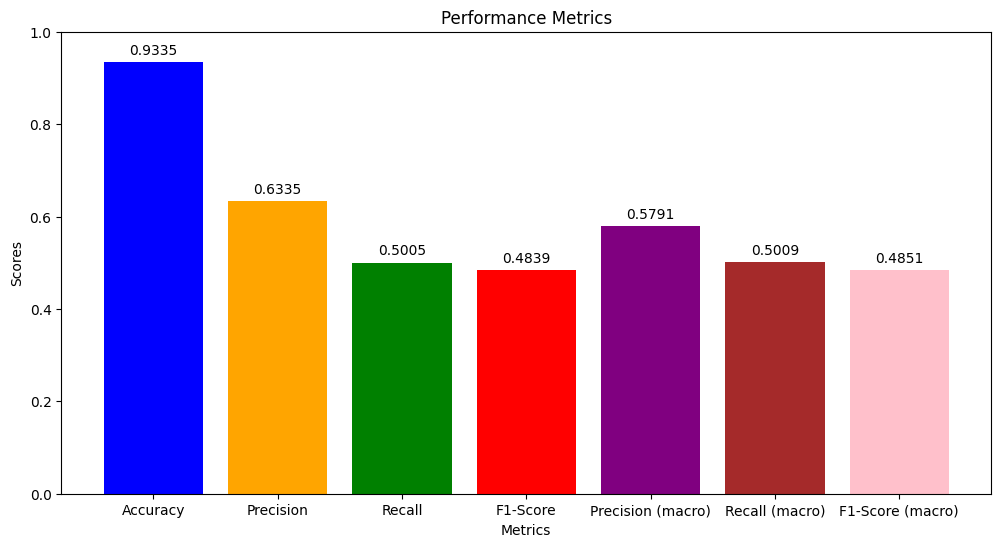

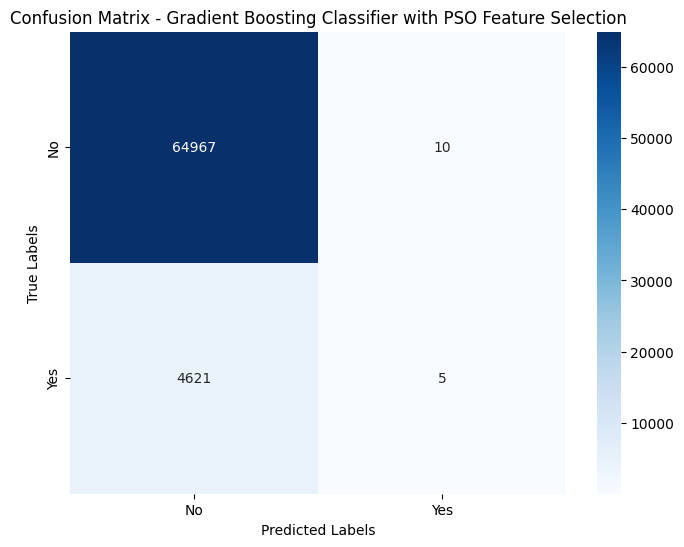

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = GradientBoostingClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Gradient Boosting Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Gradient Boosting Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()


# Get the best features data
best_features_data = X.iloc[:, best_features].values
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the Gradient Boosting model using the best features
best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_gb = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_gb = roc_auc_score(y_test_best, y_pred_prob_best_gb)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_gb:.4f}")

# ROC Analysis
fpr_best_gb, tpr_best_gb, _ = roc_curve(y_test_best, y_pred_prob_best_gb)

plt.figure()
plt.plot(fpr_best_gb, tpr_best_gb, label=f'After PSO (AUC = {auc_after_pso_gb:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Gradient Boosting after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Gradient Boosting Classifier Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best, average='macro', zero_division=1)
recall_best = recall_score(y_test_best, y_pred_best, average='macro')
f1_best = f1_score(y_test_best, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-score: {f1_best:.4f}")
print(f"Precision: {precision_best_macro:.4f}")
print(f"Recall: {recall_best_macro:.4f}")
print(f"F1-score: {f1_best_macro:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best_macro, recall_best_macro, f1_best_macro]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Gradient Boosting Classifier
cm_best = confusion_matrix(y_test_best, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Gradient Boosting Classifier with PSO Feature Selection')
plt.show()


### <center> PSO Analysis for All Machine Learning Models with PSO Algorithm

AUC after PSO (using selected features): 0.7197
AUC after PSO (using selected features): 0.6947
AUC after PSO (using selected features): 0.6961
AUC after PSO (using selected features): 0.7085
AUC after PSO (using selected features): 0.7258


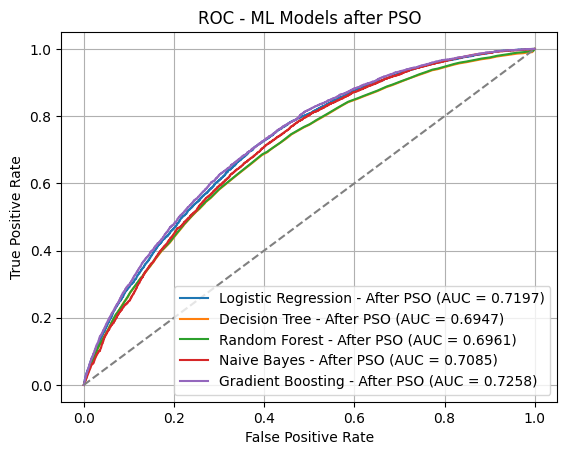

In [ ]:
# ROC Analysis
fpr_best_lr, tpr_best_lr, _ = roc_curve(y_test_best, y_pred_prob_best_lr)
fpr_best_dt, tpr_best_dt, _ = roc_curve(y_test_best, y_pred_prob_best_dt)
fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test_best, y_pred_prob_best_rf)
fpr_best_nb, tpr_best_nb, _ = roc_curve(y_test_best, y_pred_prob_best_nb)
fpr_best_gb, tpr_best_gb, _ = roc_curve(y_test_best, y_pred_prob_best_gb)
# Print the AUC after PSO
auc_after_pso_lr = roc_auc_score(y_test_best, y_pred_prob_best_lr)
print(f"AUC after PSO (using selected features): {auc_after_pso_lr:.4f}")
auc_after_pso_dt = roc_auc_score(y_test_best, y_pred_prob_best_dt)
print(f"AUC after PSO (using selected features): {auc_after_pso_dt:.4f}")
auc_after_pso_rf = roc_auc_score(y_test_best, y_pred_prob_best_rf)
print(f"AUC after PSO (using selected features): {auc_after_pso_rf:.4f}")
auc_after_pso_nb = roc_auc_score(y_test_best, y_pred_prob_best_nb)
print(f"AUC after PSO (using selected features): {auc_after_pso_nb:.4f}")
auc_after_pso_gb = roc_auc_score(y_test_best, y_pred_prob_best_gb)
print(f"AUC after PSO (using selected features): {auc_after_pso_gb:.4f}")

plt.figure()
plt.plot(fpr_best_lr, tpr_best_lr, label=f'Logistic Regression - After PSO (AUC = {auc_after_pso_lr:.4f})')
plt.plot(fpr_best_dt, tpr_best_dt, label=f'Decision Tree - After PSO (AUC = {auc_after_pso_dt:.4f})')
plt.plot(fpr_best_rf, tpr_best_rf, label=f'Random Forest - After PSO (AUC = {auc_after_pso_rf:.4f})')
plt.plot(fpr_best_nb, tpr_best_nb, label=f'Naive Bayes - After PSO (AUC = {auc_after_pso_nb:.4f})')
plt.plot(fpr_best_gb, tpr_best_gb, label=f'Gradient Boosting - After PSO (AUC = {auc_after_pso_gb:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - ML Models after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

### Find the Characteristics

#### 1. Logistic Regression

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Load your dataset
CVDRisk = pd.read_csv('CVDRisk_final_ML.csv')  # Update with the correct path to your dataset

target_variable = 'CVD_Outcome'
categorical_variables = [
    'DMT1', 'Ethnicity', 'Migraine', 'Sex', 'Smoking_Status_Qrisk3_1', 'CKD', 'AF', 'SLE', 'DMT2', 'Severe_mental_illness', 'RA', '1st_degree_relatives', 'BP_med', 'psychotic_med', 'Erectile_dysfunction_med', 'steroid_med'
]
numeric_variables = [
    'Age_at_recruitment', 'BMI_1', 'SBP_automated_reading', 'Cholesterol/HDL_ratio'
]

# Preprocessing: Encode categorical variables
le = LabelEncoder()
CVDRisk[categorical_variables] = CVDRisk[categorical_variables].apply(lambda col: le.fit_transform(col))

# Encode the target variable
le_target = LabelEncoder()
CVDRisk[target_variable] = le_target.fit_transform(CVDRisk[target_variable])

# Split the dataset into train and test sets
X = CVDRisk.drop(columns=[target_variable])
y = CVDRisk[target_variable]

# Standardize numeric variables
scaler = StandardScaler()
X[numeric_variables] = scaler.fit_transform(X[numeric_variables])

# Initialize PSO parameters
c1 = 2  # Cognitive behavior value
c2 = 2  # Social behavior value
w = 0.9  # Weight inertia
Particles = 15
Attributes = X.shape[1]

# Initialize particles and velocities using numpy
Particle_Positions = np.random.rand(Particles, Attributes)
Velocities = np.random.rand(Particles, Attributes)

Initial_iteration = 1
Max_No_Iteration = 80
Optimal_values = []

# Initialize lists to store the best features and their AUCs
best_features = None
best_auc = 0

# PSO algorithm
while Initial_iteration <= Max_No_Iteration:
    r1 = np.random.rand(1, Attributes).flatten()
    r2 = np.random.rand(1, Attributes).flatten()

    Velocities_New = []
    for row in range(Particles):
        Velocities_update = (w * Velocities[row] +
                             c1 * r1 * (Particle_Positions[row] - Particle_Positions[row]) +
                             c2 * r2 * (Particle_Positions[row] - Particle_Positions[row]))
        Velocities_New.append(Velocities_update)

    Velocities = Velocities_New

    Particle_Positions_New = []
    for row in range(Particles):
        Particle_Positions_update = Velocities_New[row] + Particle_Positions[row]
        Particle_Positions_New.append(Particle_Positions_update)

    Particle_Positions_New = [np.abs(u) for u in Particle_Positions_New]

    storing_P = []
    for i in range(Particles):
        column_indices = list(range(X.shape[1]))
        random.shuffle(column_indices)
        num_columns = random.randint(10, X.shape[1])
        selected_indices = column_indices[:num_columns]
        P = X.iloc[:, selected_indices].values
        storing_P.append((P, selected_indices))

    optimal_aucs = []
    for P, selected_indices in storing_P:
        X_train, X_test, y_train, y_test = train_test_split(P, y, test_size=0.2, random_state=42)

        # Standardize numeric variables
        if len(numeric_variables) > 0:
            scaler = StandardScaler()
            X_train[:, :len(numeric_variables)] = scaler.fit_transform(X_train[:, :len(numeric_variables)])
            X_test[:, :len(numeric_variables)] = scaler.transform(X_test[:, :len(numeric_variables)])

        model = LogisticRegression()
        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_prob)
        optimal_aucs.append((auc, selected_indices))

        if auc > best_auc:
            best_auc = auc
            best_features = selected_indices

    Max_Value_Fitness_Function = max(optimal_aucs)[0]
    Optimal_values.append(Max_Value_Fitness_Function)

    Initial_iteration += 1

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, Optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Logistic Regression Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Plot the PSO convergence curve
numbers_array = np.arange(1, Max_No_Iteration + 1)
sorted_optimal_values = sorted(Optimal_values)  # Sort the optimal values in ascending order
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(numbers_array, sorted_optimal_values, marker='o')
ax.set(title='PSO Algorithm Convergence Curve - Logistic Regression Model',
       xlabel='Number of iterations',
       ylabel='Optimal / Maximum AUC Values')
plt.show()

# Get the best features data
best_features_data = X.iloc[:, best_features].values
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(best_features_data, y, test_size=0.2, random_state=42)

# Train and evaluate the logistic regression model using the best features
best_model = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter
best_model.fit(X_train_best, y_train_best)
y_pred_prob_best_lr = best_model.predict_proba(X_test_best)[:, 1]
auc_after_pso_lr = roc_auc_score(y_test_best, y_pred_prob_best_lr)

# Print the AUC after PSO
print(f"AUC after PSO (using selected features): {auc_after_pso_lr:.4f}")

# ROC Analysis
fpr_best_lr, tpr_best_lr, _ = roc_curve(y_test_best, y_pred_prob_best_lr)

plt.figure()
plt.plot(fpr_best_lr, tpr_best_lr, label=f'After PSO (AUC = {auc_after_pso_lr:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression after PSO')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

# Print the best features and their AUC
print(f"Best AUC: {best_auc:.4f}")
print(f"Best Features: {best_features}")
print(f"Feature Names: {X.columns[best_features].tolist()}")

# Display the classification report for the best model
y_pred_best = best_model.predict(X_test_best)
classification_rep_best = classification_report(y_test_best, y_pred_best, target_names=['no', 'yes'], zero_division=1)
print("Logistic Regression Results with PSO Feature Selection:")
print(classification_rep_best)

# Display other performance metrics
accuracy_best = accuracy_score(y_test_best, y_pred_best)
precision_best = precision_score(y_test_best, y_pred_best)
recall_best = recall_score(y_test_best, y_pred_best)
f1_best = f1_score(y_test_best, y_pred_best)
precision_best_macro = precision_score(y_test_best, y_pred_best, average='macro', zero_division=1)
recall_best_macro = recall_score(y_test_best, y_pred_best, average='macro')
f1_best_macro = f1_score(y_test_best, y_pred_best, average='macro')

print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best_macro:.4f}")
print(f"Recall: {recall_best_macro:.4f}")
print(f"F1-score: {f1_best_macro:.4f}")

# Create bar chart for performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
scores = [accuracy_best, precision_best, recall_best, f1_best, precision_best_macro, recall_best_macro, f1_best_macro]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])

# Adding text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Ensure y-axis starts at 0 and ends at 1
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Metrics')
plt.show()

# Generate confusion matrix for Logistic Regression Classifier


ModuleNotFoundError: No module named 'numpy'